<a href="https://colab.research.google.com/github/Kommmi/Quantum-Dynamical-Systems/blob/main/01_GQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Global state and environment-conditioned decomposition

The global state of a multibody system can be written as when focusing on a subsystem $S_a$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{L_S}\sum_{j=1}^{L_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$

We consider a three-qubit state with one subsystem qubit $S$ and two environment qubits $E$
$$
|\Psi_{SE}\rangle =
\frac{1}{\sqrt{8}}
\left(|000\rangle+|001\rangle+|010\rangle+|011\rangle
+|100\rangle+|101\rangle+|110\rangle-|111\rangle\right).
$$

Taking the first qubit as system $S_0$ and the last two as environment $E$. The environment basis is $\{|e_j⟩\}_{j=1}^{4} = \{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}.$ The environment conditioned decomposition is:
$$
|\Psi_{SE}\rangle
=
\frac{1}{\sqrt{8}}((|0\rangle+|1\rangle)|00\rangle
+(|0\rangle+|1\rangle)|01\rangle
+(|0\rangle+|1\rangle)|10\rangle
+(|0\rangle-|1\rangle)|11\rangle) ,
$$

Further simplified as:

$$
|\Psi_{SE}\rangle
=
\frac{1}{2}|\chi_1^{S_0}\rangle|00\rangle
+\frac{1}{2}|\chi_1^{S_0}\rangle|01\rangle
+\frac{1}{2}|\chi_1^{S_0}\rangle|10\rangle
+\frac{1}{2}|\chi_2^{S_0}\rangle|11\rangle ,
$$

where

$$
|\chi_1^{S_0}\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\qquad
|\chi_1^{S_0}\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

Thus each environment outcome has probability

$$
\lambda_j^E=\frac{1}{4}.
$$

### 2. Local state: density matrix

The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho_{S_0} =
\sum_{j=1}^{4}\lambda_j^E
|\chi_j^{S_0}\rangle\langle \chi_j^{S_0}|.
$$

For this example,

$$
\rho_{S_0}
=
\frac{3}{4}|\chi_1^{S_0}\rangle\langle \chi_1^{S_0}|
+\frac{1}{4}|\chi_2^{S_0}\rangle\langle \chi_2^{S_0}|.
$$

In the computational basis,

$$
\rho_{S_0} =
\begin{pmatrix}
1/2 & 1/4 \\
1/4 & 1/2
\end{pmatrix}.
$$

This is a mixed local state, even though the full three-qubit state is pure.

### 3. Local state: geometric quantum state

The same local state can be represented as a probability measure over pure subsystem states:

$$
Q^{S_0} =
\sum_{j=1}^{4}
\lambda_j^E
\delta_{|\chi_j^{S_0}\rangle}.
$$

Since three environment outcomes give $|\chi_1^{S_0}\rangle$ and one gives $|\chi_2^{S_0}\rangle $,

$$
Q^{S_0} =
\frac{3}{4}\delta_{|\chi_1^{S_0}\rangle}
+\frac{1}{4}\delta_{|\chi_2^{S_0}\rangle}.
$$

Thus the geometric quantum state keeps track of the pure states appearing in the environment-conditioned ensemble, together with their probabilities.

In [1]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Quantum-Dynamical-Systems.git

# Move into the repo
%cd Quantum-Dynamical-Systems

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:

from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site, random_wavefunction, print_density_matrix, print_gqs_single_site, print_wavefunction
from gqs.plotsCompare import plot_gqs_and_density_matrix

Global State
(0.3707+0.6805j) |000>       + (0.3261-0.0737j) |001>       + (0.1156+0.0327j) |010>       + (-0.2716-0.0724j) |011>      +
(-0.1968+0.0071j) |100>      + (0.0760-0.1519j) |101>       + (0.2521-0.0106j) |110>       + (0.2081-0.1403j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.8057       -0.0497-0.1363j  
|1>        -0.0497+0.1363j        0.1943      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.464+0.851j) |0> + (-0.246+0.009j) |1>,0.639000
1,1,|01>,(0.870-0.197j) |0> + (0.203-0.405j) |1>,0.141000
2,2,|10>,(0.414+0.117j) |0> + (0.902-0.038j) |1>,0.078000
3,3,|11>,(-0.721-0.192j) |0> + (0.552-0.372j) |1>,0.142000


Reduced States Plot


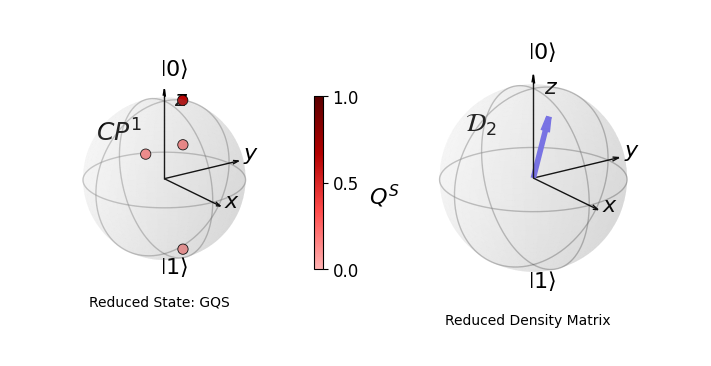

In [3]:
dhilbert = 2
nchain = 3
system_site = 0
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.6813-0.2261j) |000>       + (0.1315+0.1385j) |001>       + (-0.0302+0.2225j) |010>      + (-0.0535+0.0503j) |011>      +
(-0.1713-0.2269j) |100>      + (-0.2194-0.1566j) |101>      + (0.0331-0.1250j) |110>       + (-0.4664-0.0687j) |111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.7052        0.0648-0.1298j  
|1>         0.0648+0.1298j        0.2948      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 1
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.906-0.301j) |0> + (-0.040+0.296j) |1>,0.566000
1,1,|01>,(0.643+0.677j) |0> + (-0.262+0.246j) |1>,0.042000
2,2,|10>,(-0.548-0.727j) |0> + (0.106-0.400j) |1>,0.098000
3,3,|11>,(-0.404-0.288j) |0> + (-0.859-0.127j) |1>,0.295000


Reduced States Plot


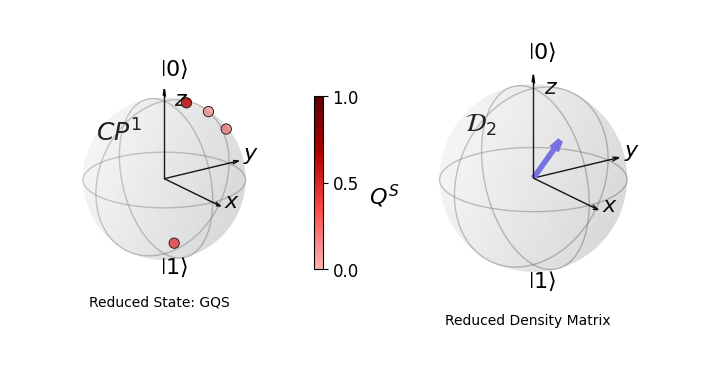

In [4]:
system_site = 1
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.2445-0.4476j) |000>       + (0.1949+0.2951j) |001>       + (-0.3717-0.2795j) |010>      + (0.0497-0.0088j) |011>       +
(-0.0176-0.2432j) |100>      + (-0.1228-0.0143j) |101>      + (-0.3960+0.1398j) |110>      + (-0.1507-0.3495j) |111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.7122       -0.0839-0.3064j  
|1>        -0.0839+0.3064j        0.2878      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 2
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.394-0.721j) |0> + (0.314+0.475j) |1>,0.385000
1,1,|01>,(-0.795-0.597j) |0> + (0.106-0.019j) |1>,0.219000
2,2,|10>,(-0.064-0.890j) |0> + (-0.449-0.052j) |1>,0.075000
3,3,|11>,(-0.699+0.247j) |0> + (-0.266-0.617j) |1>,0.321000


Reduced States Plot


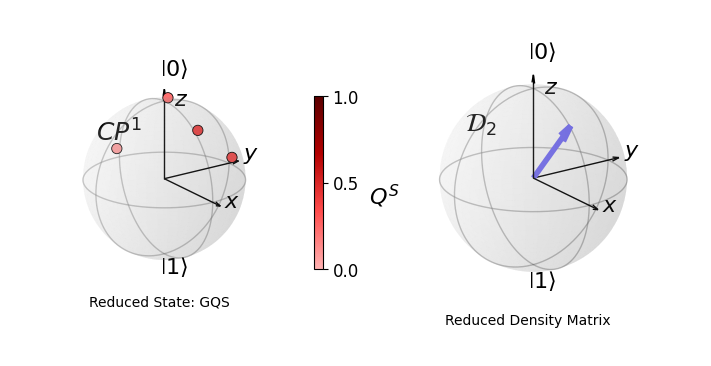

In [5]:
system_site = 2
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.2033-0.0698j) |0000>      + (0.1056-0.2981j) |0001>      + (-0.0448+0.1268j) |0010>     + (0.0406-0.1414j) |0011>      +
(0.2111+0.0309j) |0100>      + (0.1111+0.1993j) |0101>      + (-0.4854-0.0728j) |0110>     + (-0.1531-0.0885j) |0111>     +
(0.0147-0.1281j) |1000>      + (-0.1987+0.2415j) |1001>     + (0.1369+0.1534j) |1010>      + (0.0303+0.1065j) |1011>      +
(-0.1307-0.1042j) |1100>     + (0.3870+0.1141j) |1101>      + (-0.1462+0.1505j) |1110>     + (0.0185-0.2007j) |1111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.5557        0.0283+0.2081j  
|1>         0.0283-0.2081j        0.4443      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 8



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.811-0.278j) |0> + (0.058-0.511j) |1>,0.063000
1,1,|01>,(0.237-0.670j) |0> + (-0.447+0.543j) |1>,0.198000
2,2,|10>,(-0.182+0.516j) |0> + (0.557+0.624j) |1>,0.060000
3,3,|11>,(0.220-0.768j) |0> + (0.165+0.579j) |1>,0.034000
4,4,|100>,(0.779+0.114j) |0> + (-0.482-0.384j) |1>,0.073000
5,5,|101>,(0.240+0.430j) |0> + (0.835+0.246j) |1>,0.215000
6,6,|110>,(-0.909-0.136j) |0> + (-0.274+0.282j) |1>,0.285000
7,7,|111>,(-0.571-0.330j) |0> + (0.069-0.748j) |1>,0.072000


Reduced States Plot


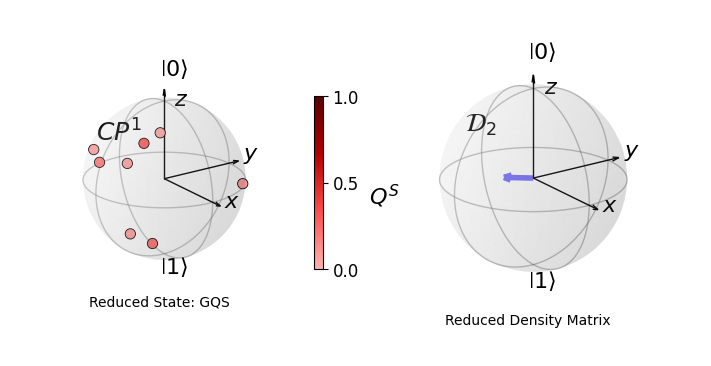

In [6]:
dhilbert = 2
nchain = 4
system_site = 0
psi = random_wavefunction(4)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)

Global State
(0.0056+0.1840j) |00000>     + (0.2438+0.0430j) |00001>     + (-0.0571-0.0679j) |00010>    + (0.0701+0.1328j) |00011>     +
(0.0620+0.3259j) |00100>     + (-0.0121-0.0850j) |00101>    + (-0.2253+0.1216j) |00110>    + (-0.1596+0.1475j) |00111>    +
(0.1036+0.0376j) |01000>     + (-0.0934+0.1639j) |01001>    + (-0.0043-0.0158j) |01010>    + (-0.0098-0.1028j) |01011>    +
(-0.1201-0.2257j) |01100>    + (-0.0880+0.3165j) |01101>    + (0.0073-0.0491j) |01110>     + (-0.0377+0.0689j) |01111>    +
(-0.1007+0.1010j) |10000>    + (0.0344-0.2184j) |10001>     + (0.0405-0.1053j) |10010>     + (-0.2236-0.1110j) |10011>    +
(0.1390+0.1766j) |10100>     + (-0.1038+0.1119j) |10101>    + (0.0364+0.0745j) |10110>     + (-0.0854+0.1461j) |10111>    +
(-0.0704-0.0398j) |11000>    + (-0.0313+0.0013j) |11001>    + (-0.1165+0.2545j) |11010>    + (-0.0135-0.1612j) |11011>    +
(0.0753-0.0589j) |11100>     + (-0.0573-0.0943j) |11101>    + (-0.0496+0.0598j) |11110>    + (0.1030+0.0106j) |11111>  

,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.024+0.790j) |0> + (-0.432+0.434j) |1>,0.054000
1,1,|01>,(0.735+0.130j) |0> + (0.104-0.658j) |1>,0.110000
2,2,|10>,(-0.398-0.473j) |0> + (0.282-0.734j) |1>,0.021000
3,3,|11>,(0.241+0.456j) |0> + (-0.768-0.381j) |1>,0.085000
4,4,|100>,(0.155+0.813j) |0> + (0.347+0.441j) |1>,0.161000
5,5,|101>,(-0.069-0.485j) |0> + (-0.593+0.639j) |1>,0.031000
6,6,|110>,(-0.837+0.452j) |0> + (0.135+0.277j) |1>,0.072000
7,7,|111>,(-0.579+0.536j) |0> + (-0.310+0.530j) |1>,0.076000
8,8,|1000>,(0.758+0.275j) |0> + (-0.515-0.291j) |1>,0.019000
9,9,|1001>,(-0.488+0.857j) |0> + (-0.164+0.007j) |1>,0.037000


Reduced States Plot


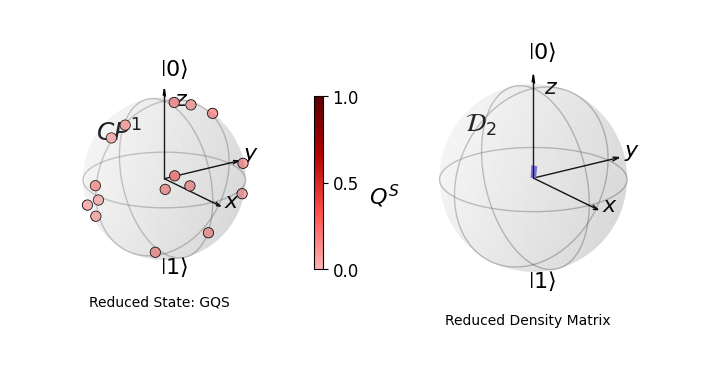

In [7]:
dhilbert = 2
nchain = 5
system_site = 0
psi = random_wavefunction(5)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)